# Fire Perimeter of the Palisades and Eaton wildfires in Los Angeles County
- Author: `Marie Tolteca`
- Date: 11/20/2025
- Github: https://github.com/marietolteca00/eds220-hwk4.git

### Purpose
A `nc` will be used for the raster (landsat) of Los Angeles County where two wildfires occured during the year 2025. The first is a simplified collection of bands (red, green, blue, near-infrared and shortwave infrared) from the Landsat Collection 2 Level-2 atmosperically adjusted surface reflectance data, obtained by the Landsat 8 satellite. Using the wildfire shapefiles project them onto the Landsat to view where the fires occured.

### About Data
Microsoft Planetary Computer, 'https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2', is used in this notebook that outlines the fire perimeters for the Palisades and Eaton Fire. This was our data landsat data for the fire perimeters. `landsat8-2025-02-23-palisades-eaton.nc`

From the County of Los Angeles GIS, 'https://egis-lacounty.hub.arcgis.com/maps/ad51845ea5fb4eb483bc2a7c38b2370c/about', was retrieved for both fire perimeters of `Palisades` and `Eaton` fire as a shapefile (shp) each were added to a folder. 

- `eaton_boundary`:` Layer contains a dissolved fire perimeter for the eaton fire. (01/21/2025)
- `palisades_boundary`: Layer contains a dissolved fire perimeter for the palisades fire. (01/21/2025)
- `landsat`: This `nc` file contains a collection of bands (red, blue, green, near-infrared, and shortwave infrared) from the Landsat Collection 2 Level-2 atmosperically adjusted surface reflectance data, obtained by the Landsat 8 satellite. This data has been clipped to an area of Los Angeles County to include both fire perimeters.

### Highlights:
- Data Exploration
- Restoring geospatial information
- True Color Image
- False color image

### Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.patches as mpatches



### Import Data

In [24]:
# Import landsat `nc` file
landsat = xr.open_dataset('data/landsat8-2025-02-23-palisades-eaton.nc')

# Import states data
fp = os.path.join('data/eaton_perimeter/Eaton_Perimeter_20250121.shp')
eaton = gpd.read_file(fp)
fp = os.path.join('data/palisades_perimeter/Palisades_Perimeter_20250121.shp')
palisades = gpd.read_file(fp)
eji = gpd.read_file(os.path.join("data","EJI_2024_California","EJI_2024_California.gdb"))



# Data Exploration

In [3]:
# View 
landsat.head()


<xarray.Dataset> Size: 596B
Dimensions:      (y: 5, x: 5)
Coordinates:
  * y            (y) float64 40B 3.799e+06 3.799e+06 ... 3.799e+06 3.799e+06
  * x            (x) float64 40B 3.344e+05 3.344e+05 ... 3.345e+05 3.345e+05
    time         datetime64[ns] 8B ...
Data variables:
    red          (y, x) float32 100B ...
    green        (y, x) float32 100B ...
    blue         (y, x) float32 100B ...
    nir08        (y, x) float32 100B ...
    swir22       (y, x) float32 100B ...
    spatial_ref  int64 8B ...

### Check CRS for Palisade Boundary

In [4]:
# Check CRS
print(f"CRS: {palisades.crs}") # CRS = EPSG:3857

# Check bounds
print(palisades.total_bounds)

# View first five rows
palisades.head()

CRS: EPSG:3857
[-13212082.926963     4032822.81114236 -13191297.3200706
   4046185.03346286]


,OBJECTID,type,Shape__Are,Shape__Len,geometry
0,1,Heat Perimeter,1182.082031,267.101144,"POLYGON ((-13193543.302 4032913.077, -13193543..."
1,2,Heat Perimeter,2222.488281,185.498783,"POLYGON ((-13193524.155 4033067.953, -13193524..."
2,3,Heat Perimeter,21.011719,22.412814,"POLYGON ((-13193598.085 4033158.222, -13193598..."
3,4,Heat Perimeter,214.992188,76.639180,"POLYGON ((-13193654.249 4033146.033, -13193656..."
4,5,Heat Perimeter,44203.453125,1569.259764,"POLYGON ((-13194209.580 4033236.320, -13194209..."


### Check CRS for Eaton Boundary

In [5]:
# Check CRS
print(f"CRS: {eaton.crs}") # CRS = EPSG:3857

# Check bounds
print(eaton.total_bounds)

# View first five rows
eaton.head()

CRS: EPSG:3857
[-13153741.463466     4050560.93661453 -13137152.8556185
   4060781.94401591]


,OBJECTID,type,Shape__Are,Shape__Len,geometry
0,1,Heat Perimeter,2206.265625,270.199719,"POLYGON ((-13146936.686 4051222.067, -13146932..."
1,2,Heat Perimeter,20710.207031,839.204218,"POLYGON ((-13150835.463 4052713.929, -13150831..."
2,3,Heat Perimeter,3639.238281,250.304502,"POLYGON ((-13153094.697 4053057.596, -13153113..."
3,4,Heat Perimeter,1464.550781,148.106792,"POLYGON ((-13145097.740 4053118.235, -13145100..."
4,5,Heat Perimeter,4132.753906,247.960744,"POLYGON ((-13153131.126 4053196.882, -13153131..."


####  Column names to lowercase for consistency 


In [25]:
# Lower column titles on dataframes
for df in [palisades, eaton]:
    df.columns = df.columns.str.lower()

# Match CRS
eaton.crs == palisades.crs  # False
print(f' The CRS for Eaton is: {eaton.crs} and the crs for palisades is: {palisades.crs}')

# Transform CRS
eji = eji.to_crs(palisades.crs)


# Check CRS match
assert eji.crs == palisades.crs
print("The EJI CRS match with Palisades CRS, after transformation :)")

# Join    
palisadesjoin = gpd.sjoin(eji,palisades)
eatonjoin = gpd.sjoin(eji, eaton)

# Clipping 
palisades_clip = gpd.clip(eji, palisades)
eaton_clip = gpd.clip(eji, eaton)

 The CRS for Eaton is: EPSG:3857 and the crs for palisades is: EPSG:3857
The EJI CRS match with Palisades CRS, after transformation :)


#### View Fire Perimeter Boundary - Palisades and Eaton

Text(0.5, 1.0, 'Eaton Fire Perimeter')

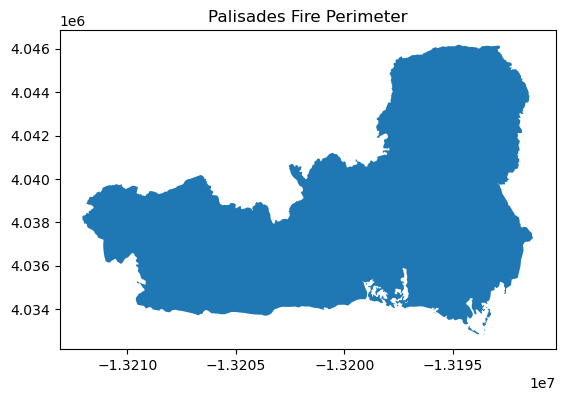

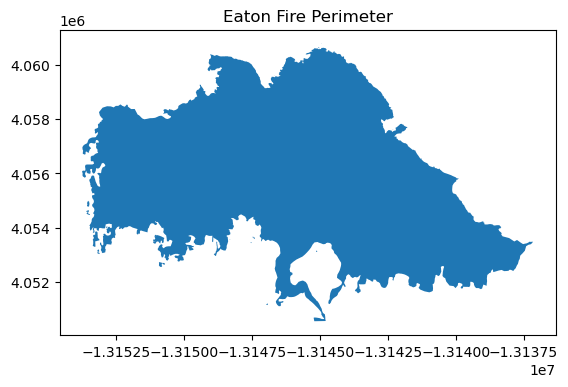

In [7]:
# View DF map
palisades.plot()
plt.title('Palisades Fire Perimeter')


# Second Map
eaton.plot()
plt.title('Eaton Fire Perimeter')



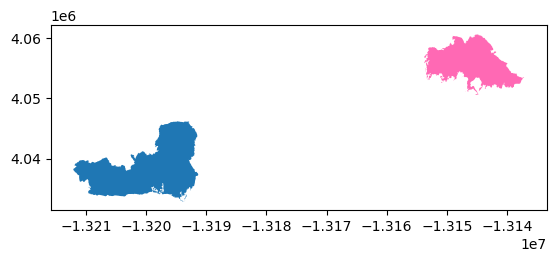

In [8]:
fig, ax = plt.subplots()

palisades.plot(ax=ax)
eaton.plot(ax=ax, color = 'hotpink')
plt.title('')

plt.show()

#### Check if CRS's are geographic and projected
1. Check Palisades
2. Check Eaton

In [9]:
print(f"{'Is the CRS geographic for palisades?' : <25} {palisades.crs.is_geographic}")
print(f"{'Is the CRS projected for palisades?' : <25} {palisades.crs.is_projected}")

print(f"{'Is the CRS geographic for eaton?' : <25} {eaton.crs.is_geographic}")
print(f"{'Is the CRS projected for eaton?' : <25} {eaton.crs.is_projected}")

Is the CRS geographic for palisades? False
Is the CRS projected for palisades? True
Is the CRS geographic for eaton? False
Is the CRS projected for eaton? True


#### Summary of Data Exploration:
Through my preliminary data exploration I was able to know the bounding box for both fire perimeters (Palisades and Eaton). Both datasets have the same CRS, I also changed the name of the columns on both datasets to be lowered. I also viewed the landsat, nc file, to view the dimensions and noticed it had floats on the x and y axis, as well as a datetime series for time. 

### Restore Geospatial Information to Landsat Data
NetCDF files sometimes lose CRS information. Here, we extract the CRS from `spatial_ref` and write it to the dataset so that we can overlay shapefiles correctly.


In [10]:
# Check CRS of Landsat
print(f"CRS:, {landsat.rio.crs}")

# Extract CRS using spatial_ref variable
wkt = landsat.spatial_ref.crs_wkt
print("\nCRS WKT from spatial_ref:")
print(wkt)

# Write the CRS to the dataset - geospatial information and spatial reference
landsat = landsat.rio.write_crs(wkt, inplace=False)

# Verify CRS is now attached
print("\nCRS after writing:", landsat.rio.crs)


CRS:, None

CRS WKT from spatial_ref:
PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]

CRS after writing: EPSG:32611


# True color image
- Select the red, green, and blue (RGB) variables (in that order) of the xarray. Dataset holding the Landsat data.
- Convert it to a numpy.array using the to_array() method. Will give `two errors`, they will be fixed following that code chunk
- Plot to create an RGB image with the data to create a true color image of the area.
- Handle NaN values to prevent plotting errors caused by clouds or missing pixels.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


/Users/marietolteca/opt/anaconda3/envs/eds220-env/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


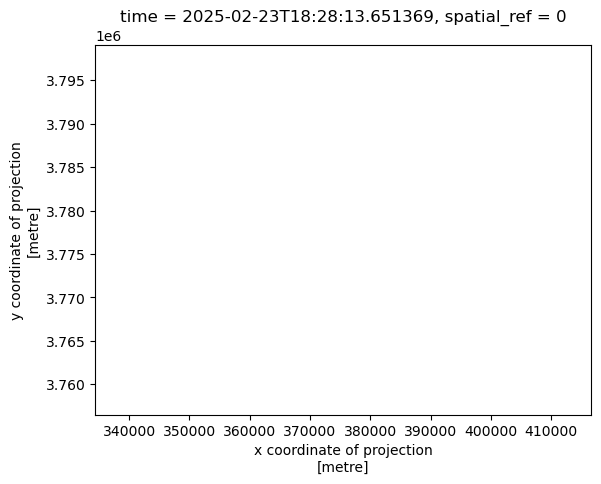

In [11]:
# Select RGB bands
rgb = landsat[["red", "green", "blue"]]

# Convert to numpy.array 
rgb_array = rgb.to_array()

# Plot with robust=True (handles outliers like clouds)
rgb_array.plot.imshow()

The plot is empty because there are NA values in the xarray, as well as arguments are needed such as vmax, vmin, and robust.

In [12]:
# Identify which bands have NAN values
np.isnan(rgb_array).any(dim=["x", "y"])


<xarray.DataArray (variable: 3)> Size: 3B
array([False,  True,  True])
Coordinates:
    time         datetime64[ns] 8B ...
    spatial_ref  int64 8B 0
  * variable     (variable) object 24B 'red' 'green' 'blue'

In [13]:
# Check `nan` values in a for-loop
for band in ["red", "green", "blue"]:
    print(band, landsat[band].isnull().any().item())


red False
green True
blue True


Fill NA Values into collection of bands Red, green, and blue. This allows for `no NaN` error message to be removed.

In [14]:
#  Substitue any NAN values as 0
landsat_filled = landsat.fillna(0)

# Add fillna() back into rgb
rgb_filled = landsat_filled[["red", "green", "blue"]].to_array()


#### Use `plot.imshow(robust=True)` to view satellite imagery

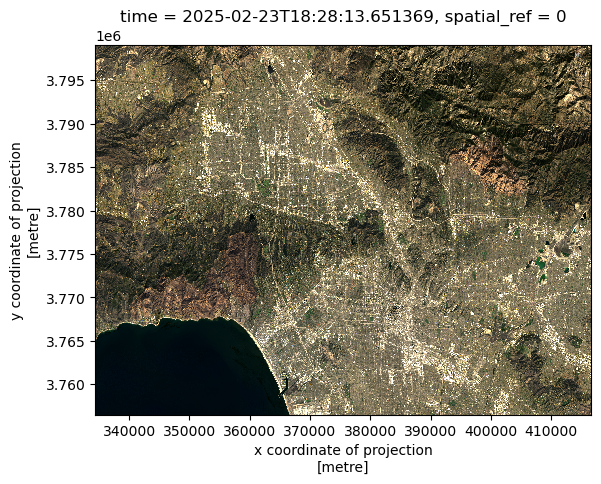

In [15]:
# View plot- No longer gives errors
rgb_filled.plot.imshow(robust = True)

The first output, warning message were given aswell as the bands had NaN values which caused the errors as well as not accounting for cloud coverage, reflections, missing pixels, and shadows. In the second output, after replacing NaN values, the message no longer shows, the image has no missing pixels and it is clearer.

# False color image
Without creating any new variables, create a false color image by plotting the short-wave infrared (swir22), near-infrared, and red variables (in that order).

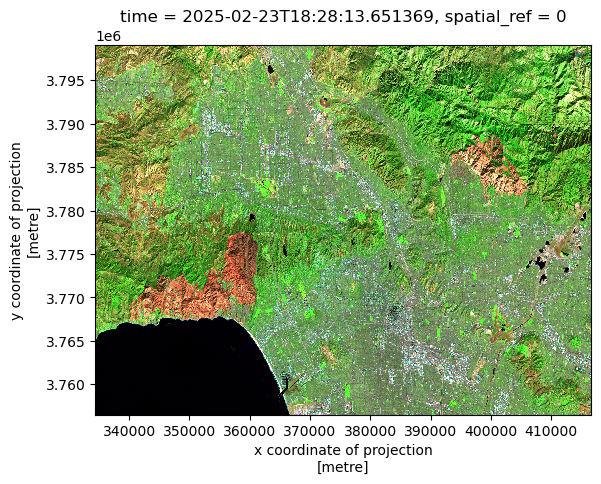

In [16]:
# Use chaining method - Convert to numpy array, then plot
landsat[['swir22', 'nir08', 'red']].to_array().plot.imshow(robust=True)


# Final Map
##### Process
- Create a map showing the shortwave infrared/near-infrared/red false color image together with both fire perimeters. 
- Customize it appropriately including, at least, an informative title and legend. You may also want to include text on the map to identify which fire is which.

In [17]:
# Assign numpy array to a variable
false_color = landsat[["swir22", "nir08", "red"]].to_array()

#### Match CRS

In [18]:
# Check Landsat CRS
print(landsat.rio.crs)

EPSG:32611


In [19]:
# Check Eaton CRS
print("Eaton CRS:", eaton.crs)

Eaton CRS: EPSG:3857


In [20]:
# Check Palisades CRS
print("Palisades CRS:", palisades.crs)

Palisades CRS: EPSG:3857


#### Transform Fire Perimeters to match landsat

In [21]:
# Transform Fire Perimeters to match landsat
eaton = eaton.to_crs(landsat.rio.crs)
palisades = palisades.to_crs(landsat.rio.crs)

# Check transformation
print("Eaton CRS:", eaton.crs) # EPSG:32611
print("Palisades CRS:", palisades.crs) # EPSG:32611

Eaton CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
Palisades CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central

# Spatial join and clip

<function matplotlib.pyplot.show(close=None, block=None)>

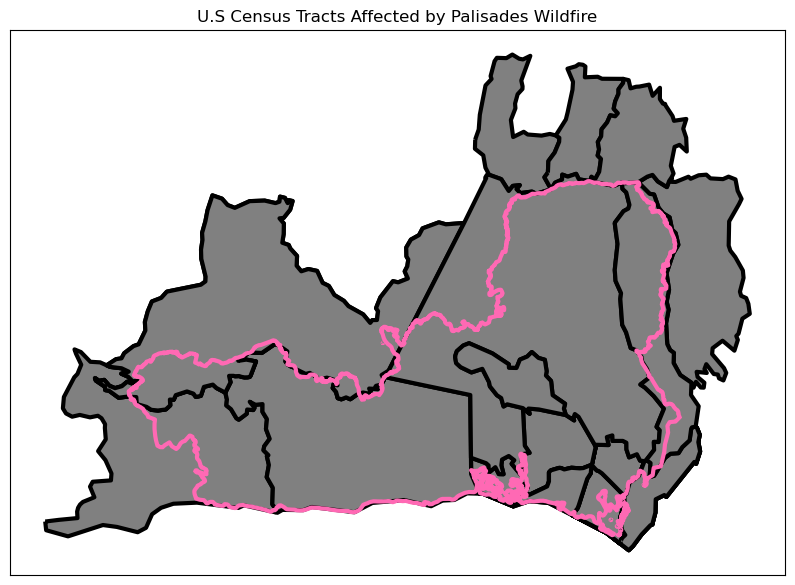

In [28]:
# Define figure and axis dimensions
fig, ax= plt.subplots(figsize = (10,8))

# Plot the joined EJI and Palisades

# Clipping 
#palisades_clip = gpd.clip(eji, palisades)
#eaton_clip = gpd.clip(eji, eaton)

palisadesjoin.plot(ax=ax, edgecolor= "black", facecolor= "grey", linewidth = 3)
palisades.plot(ax=ax, edgecolor= "hotpink", color= "none", linewidth = 3)
#eatonjoin.plot(ax=ax, edgecolor= "none,", color= "none", linewidth = 3)

# Set title
ax.set_title("U.S Census Tracts Affected by Palisades Wildfire")

# Turn off axis ticks
ax.set_xticks([])
ax.set_yticks([])

# Show plot
plt.show

### Create Map
Plot the False-Color imagery generated along with both fire perimeters, eaton and palisades boundary, using landsat.

In [ ]:
# Set up fig, ax
fig, ax = plt.subplots(figsize=(10,10))

# Plot false-color background first
false_color.plot.imshow(robust=True)

# Overlay fire perimeters
eaton.boundary.plot(ax=ax, color="hotpink", linewidth=2, label="Eaton Fire", facecolor = "lightpink", alpha = 0.6)
palisades.boundary.plot(ax=ax, color="red", linewidth=2, label="Palisades Fire", facecolor = "indianred", alpha = 0.6)

# Legend Patches
pal_legend = mpatches.Patch(facecolor="indianred", edgecolor="red", alpha=0.6, label="Palisades Fire")
eaton_legend = mpatches.Patch(facecolor="lightpink", edgecolor="hotpink", alpha=0.6, label="Eaton Fire")

# Zoom to fire extents - This is for the bound limits
xmin = min(eaton.total_bounds[0], palisades.total_bounds[0]) - 500
xmax = max(eaton.total_bounds[2], palisades.total_bounds[2]) + 500
ymin = min(eaton.total_bounds[1], palisades.total_bounds[1]) - 500
ymax = max(eaton.total_bounds[3], palisades.total_bounds[3]) + 500

# Set limits
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax) 

# Title
ax.set_title("SWIR-NIR-Red False Color Composite with Fire Perimeters")

# Legend
#ax.legend(loc = "upper left")

ax.legend(handles=[eaton_legend, pal_legend], 
          loc="upper left",
          title="Fire Perimeters",
          # Background of legend
          frameon=True)
ax.set_axis_off()
plt.show()

In this figure we are able to clearly see the areas that were affected by the wildfire that happened in Los Angeles County. With the false color imagery, it uses SWIR22 for red, NIR08 for green, and the Red band for blue. Bright green areas indicate healthy vegetation, while brown or muted areas correspond to bare ground or soil. The fire-affected regions are visible within the outlined perimeters. The fire perimeter of Palisades fire (red) and Eaton fire (pink) are identified by the colored boundary and an added text for easier identification. In this figure we are able to view both landscapes in Los Angeles and the fire perimeters that most recently occured.


# References:

- Microsoft Planetary Computer. Planetary Computer. (n.d.). `https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2`
- NIFC FIRIS The source of the hosted service/dataset. `https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/ArcGIS/rest/services/CA_` Perimeters 
- Palisades and eaton dissolved fire perimeters (2025). County Of Los Angeles Enterprise GIS. (2025, January 21). `https://egis-lacounty.hub.arcgis.com/maps/ad51845ea5fb4eb483bc2a7c38b2370c/about `
